# Evaluación 3

**Integrantes:**

+ Integrante 1: Benjamín Alejandro Ibáñez Verdejo : benjamin.ibanez2201@alumnos.ubiobio.cl
+ Integrante 2: Catalina Montserrat Muñoz Durán : catalina.munoz2201@alumnos.ubiobio.cl

**Fecha de Entrega:** 27 Noviembre 2025 antes de las 18:00  


---

## Descripción

Este notebook contiene el desarrollo de la evaluación 3 de la asignatura de Inteligencia Artificial de la carrera Ingeniería Civil en Informática de la Universidad del Biío Bío - Sede Concepción

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (2.2.2)
- numpy (2.0.2)
- matplotlib (3.10.0)
- sklearn (1.6.1)
- seaborn (0.13.2)

Para verificar la versión instalada ejecutar usando el nombre del paquete del cual quieres saber la versión; por ejemplo, si quieres saber la versión de numpy usas:

```python
import numpy
print(numpy.__version__)
````

In [1]:
# Descargar el archivo y guardarlo en el entorno
!wget https://raw.githubusercontent.com/JaznaLaProfe/InteligenciaArtificial/master/data/data_riesgo_credito.csv

--2025-11-27 19:27:33--  https://raw.githubusercontent.com/JaznaLaProfe/InteligenciaArtificial/master/data/data_riesgo_credito.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163635 (160K) [text/plain]
Saving to: ‘data_riesgo_credito.csv.1’

data_riesgo_credito 100%[===================>] 159.80K  --.-KB/s    in 0.02s   

2025-11-27 19:27:34 (6.75 MB/s) - ‘data_riesgo_credito.csv.1’ saved [163635/163635]



# Indicadores evaluación

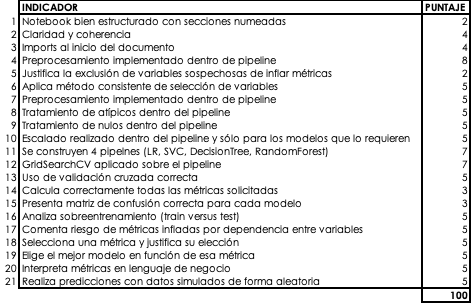

---
## Cálculo de calificación (grupal) - 40% de la calificación final

$Calificación_{proyecto} = \sum^{21}_i{item_i}$


$Calificación_{grupal} = Calificación_{proyecto}*(1-\sum^{4}_i{penalización_i})$

---

Finalmente, se aplica un porcentaje de exigencia del 51% para obtener la calificación para aprobar (4.0)

## Cálculo de calificación individual - 60% de la calificación final

✅ Responde a la pregunta de forma correcta - **7,0**

🟡 Responde a la pregunta de forma medianamante correcta - **4,0**

🔴 Responde a la pregunta de forma incorrecta - **2,0**

🔴 No responde - **1,0**

---


## Cálculo de final

$Calificacion_{final} = Calificacion_{grupal}*0,4 + Calificacion_{individual}*0,4$

---


## Penalizaciones
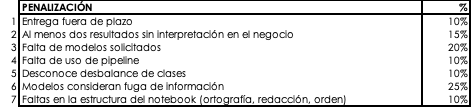

---


# Requerimientos

**RQ1.** Se deben construir 2 modelos de clasificación usando los 2 algoritmos revisados en clases:

+ `DecisionTreeClassifier`
+ `RandomForest`

Los modelos predictivos deben predecir si un cliente está en riesgo crediticio o no (variable `cliente_riesgoso`).

**RQ2.** Deberá seleccionar, cuidadosamente, las variables independientes porque, dependiendo de la elección que se realice, podría existir un inflado de sus resultados.

**RQ3.** Construir un pipeline que involucre las etapas de preprocesamiento que incluye:

+ Tratamiento de atípicos
+ Tratamiento de nulos
+ Escalado

**RQ4.** Construir dos pipelines, uno para cada modelo, que permita crear el modelo a partir de su algoritmo asociado. Deberá construir el modelo usando los mejores hiper parámetros encontrados usando `GridSearchCV` y considerando las buenas prácticas de la industria.

**RQ5.** Calcular para todos los modelos construidos las siguientes métricas:

+ Accuracy
+ Precision
+ F1-score
+ Recall
+ Matriz de confusión

**RQ6.** Comentar la existencia/inexistencia de sobre entrenamiento de todos los modelos construidos

**RQ7.** Considerando todos los modelos anteriores:

+ Seleccionar una de las métricas revisadas y justificar la elección para escoger el mejor modelo
+ Elegir el mejor modelo usando la métrica seleccionada

**RQ8.** Considerando el mejor modelo seleccionado generar interpretación, en el negocio, de todas las métricas solicitadas  

**RQ9.** Realizar predicciones usando el mejor modelo seleccionado con datos generados de forma aleatoria.

---
#1.Carga de librerías y clase winsorizer

In [2]:
# Librerías
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV


from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score,  classification_report
from sklearn.base import BaseEstimator, TransformerMixin


In [3]:
#Definición de Windsorizer
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col], lower, upper)
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)

---
#2.Carga de datos

In [4]:
# pequeña vista de la data
data = pd.read_csv("data_riesgo_credito.csv")
print("Dimensiones del dataset: ", data.shape)
display(data.head())

Dimensiones del dataset:  (3000, 9)


,Unnamed: 0,default_riesgo,ingreso_anual,edad,n_transacciones,segmento_cliente,region,score,cliente_riesgoso
0,0,0,659000,46,19,Bronze,Sur,0.164628,NO
1,1,1,592600,44,21,Silver,Norte,0.589990,YES
2,2,0,602500,42,13,Bronze,Centro,0.047850,NO
3,3,0,295100,52,15,Bronze,Norte,0.053896,NO
4,4,0,681800,35,19,Silver,Norte,-0.086074,NO


---
# 3.Análisis exploratorio de datos (EDA)

### Distribución de la variable objetivo

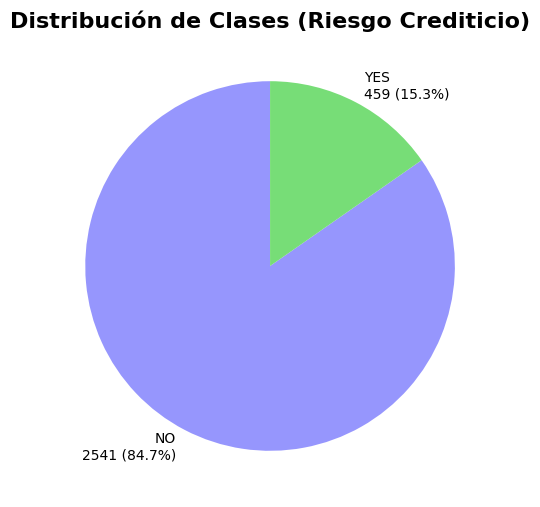

In [5]:
# --- Visualización del Desbalance de Clases ---
target_col = 'cliente_riesgoso'

conteo_clases = data[target_col].value_counts()
clases = conteo_clases.values
etiquetas = conteo_clases.index

# Crear leyendas con porcentajes
labels = [f"{label}\n{count} ({count/sum(clases):.1%})" for label, count in zip(etiquetas, clases)]

# Gráfico
plt.figure(figsize=(6, 6))
plt.pie(clases, labels=labels, colors=['#9696fd','#77dd77'], autopct='', startangle=90)
plt.title('Distribución de Clases (Riesgo Crediticio)', fontsize=16, fontweight="bold")
plt.show()

**Observaciones**

- La clase mayoritaria es la "NO riesgoso", representando aproximadamente el 84.7% del total de clientes.
- La clase minoritaria es la "Riesgoso" o "YES", con solo 15.3% de los clientes.

### Matriz de correlación

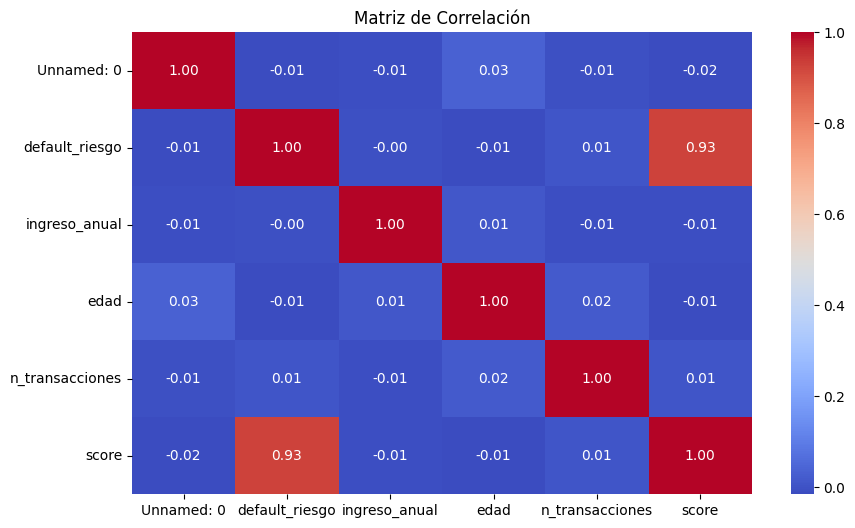

In [6]:
# Análisis de Correlación (Usando 'default_riesgo' como referencia numérica)
plt.figure(figsize=(10, 6))
numeric_df = data.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

# Mapa de calor
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

**Observaciones**
- La variable `score` presenta una correlación extremadamente alta con la variable objetivo, lo que confima la existencia de un Data Leakage implícito. Incluirla en el modelo garantizaba métricas infladas.



---
#4.Limpieza y selección de variables

In [7]:
# ============================================
#  RQ2: SELECCIÓN DE VARIABLES Y DATA LEAKAGE
# ============================================

# Definición del Target (Objetivo)
target = 'cliente_riesgoso'

# Selección de Variables (Eliminación de Fugas y Basura)
cols_to_drop = ['Unnamed: 0', 'score', 'default_riesgo']

# Validamos que existan antes de borrar
cols_to_drop_final = [c for c in cols_to_drop if c in data.columns]
print(f"\n Eliminando variables por Data Leakage o irrelevancia: {cols_to_drop_final}")


 Eliminando variables por Data Leakage o irrelevancia: ['Unnamed: 0', 'score', 'default_riesgo']


#### Justificación de selección de variables y eliminación de variables sospechosas

----

Para asegurar la validez del modelo y evitar sobreajuste o métricas  infladas, se realizó un análisis de las variables disponibles. A partir de este proceso, se decidió eliminar las siguientes:

#### > `Unnamed: 0` — Eliminada por Irrelevancia

**Motivo:**  
Corresponde a un índice o identificador único de cada fila.

**Justificación:**  
Los identificadores no aportan información útil sobre el comportamiento del cliente.  
Además, pueden inducir al modelo a memorizar datos específicos (ruido) en lugar de aprender patrones generalizables.

---

#### > `default_riesgo` — Eliminada por Data Leakage Explícito

**Motivo:**  
Es una representación binaria idéntica a la variable objetivo `cliente_riesgoso`  
(0 y 1 vs. NO y YES).

**Justificación:**  
Incluirla entregaría al modelo la respuesta correcta de antemano (correlación del 100%).  
Esto invalida completamente el proceso de predicción y genera resultados engañosos.

---

#### > `score` — Eliminada por Data Leakage Implícito / Inflación de Métricas

**Motivo:**  
Presentó una correlación extremadamente alta (**0.93**) con la variable objetivo.

**Justificación:**  
Una correlación tan elevada indica que `score` no es una variable independiente real, sino un cálculo derivado del mismo riesgo que se intenta predecir.  
Si se incluye, los modelos ignorarán variables relevantes (edad, ingresos, región, etc.), produciendo métricas artificialmente perfectas que no se replicarán en un entorno real.

### División de datos (train/test)


In [8]:
# Limpiar x
X = data.drop(columns=cols_to_drop_final + [target], errors='ignore')

# preparar y (target)
# se transforma yes/no a 1/0
le = LabelEncoder()
y = le.fit_transform(data[target])

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nDatos listos. Variables finales en X: {list(X.columns)}")
print(f"Dimensiones Train: {X_train.shape} | Test: {X_test.shape}")


Datos listos. Variables finales en X: ['ingreso_anual', 'edad', 'n_transacciones', 'segmento_cliente', 'region']
Dimensiones Train: (2100, 5) | Test: (900, 5)


---
# 5.Pipeline de prepocesamiento

In [9]:
# ================================================================
#  RQ3: PIPELINE DE PREPROCESAMIENTO (Atípicos, Nulos, Escalado)
# ================================================================

# Identificar columnas automáticamente
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Pipeline Numérico: Winsorizer -> Imputer (Mediana) -> Scaler
numeric_transformer = Pipeline(steps=[
    ('winsorizer', Winsorizer(limits=(0.05, 0.05))),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Categórico: Imputer (Moda) -> OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Unir todo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

print("Pipeline de preprocesamiento listo.")

Pipeline de preprocesamiento listo.


---
# 6.Entrenamiento de modelos

In [10]:
#==============================================================================
#  RQ1 y RQ4: CONSTRUCCIÓN DE MODELOS Y BÚSQUEDA DE HIPERPARÁMETROS (GRIDSEARCH)
# ==============================================================================

# --- ARBOL DE DECISIÓN ---
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_split': [10, 20, 30],
    'model__min_samples_leaf': [10, 20, 30],
    'model__class_weight': ['balanced']
}

# Búsqueda de Hiperparámetros
print("Entrenando Decision Tree...")
grid_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=10, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)


print(f"Mejores params DT: {grid_dt.best_params_}")

Entrenando Decision Tree...
Mejores params DT: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 30, 'model__min_samples_split': 10}


In [11]:
# --- RANDOM FOREST ---
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 4],
    'model__min_samples_split': [20, 30],
    'model__min_samples_leaf': [5, 10],
    'model__class_weight': ['balanced', None]
}

print("Entrenando Random Forest...")
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=10, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"Mejores params RF: {grid_rf.best_params_}")

Entrenando Random Forest...
Mejores params RF: {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__min_samples_split': 30, 'model__n_estimators': 100}


---
### Justificación del modelo
- Se utiliza F1 debido al desbalance entre las clases, priorizando el equilibrio entre precision y recall. Accuracy no es adecuada porque puede inflarse prediciendo siempre la clase mayoritaria.
- Para el GridSearch del **árbol**, se limita la profundidad y tamaño mínimo de hojas para evitar sobreajuste, ya que el dataset tiene pocas variables relevantes y riesgo de memorizar ruido.
- Para el GridSearch del **random forest**, se utiliza un rango moderado de profundidad para mantener interpretabilidad y evitar modelos demasiado complejos. Random Forest con árboles muy profundos tiende a overfit si las variables son pocas o ruidosas.

---

In [12]:
# ============================================================
#  RQ5: Selección de los mejores modelos según F1 (GridSearch)
# ============================================================

# 1. Extraer los mejores modelos del GridSearch
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_

# 2. Mostrar los mejores parámetros encontrados
print("Mejores parámetros Decision Tree:", grid_dt.best_params_)
print("Mejor F1 (promedio CV) Decision Tree:", grid_dt.best_score_)
print("-" * 30)
print("Mejores parámetros Random Forest:", grid_rf.best_params_)
print("Mejor F1 (promedio CV) Random Forest:", grid_rf.best_score_)

Mejores parámetros Decision Tree: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 30, 'model__min_samples_split': 10}
Mejor F1 (promedio CV) Decision Tree: 0.2518786043173004
------------------------------
Mejores parámetros Random Forest: {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__min_samples_split': 30, 'model__n_estimators': 100}
Mejor F1 (promedio CV) Random Forest: 0.19552242872513456


### Resumen del GridSearchCV

In [13]:
grid_dt

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['ingreso_anual',
                                                                          'edad',
                                                                          'n_transacciones']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          On...
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['segmento_cliente',
                                                                          'region'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': ['balanced'],
                         'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [2, 3, 4],
                         'model__min_samples_leaf': [10, 20, 30],
                         'model__min_samples_split': [10, 20, 30]},
             scoring='f1')

In [14]:
grid_rf

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['ingreso_anual',
                                                                          'edad',
                                                                          'n_transacciones']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          On...t',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['segmento_cliente',
                                                                          'region'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': ['balanced', None],
                         'model__max_depth': [3, 4],
                         'model__min_samples_leaf': [5, 10],
                         'model__min_samples_split': [20, 30],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

# 7.Evaluación de métricas



In [15]:
# 1. Definir función para calcular TODAS las métricas del RQ5
def evaluar_completo(modelo, X_train, y_train, X_test, y_test, nombre):
    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Métricas solicitadas
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'F1-Score': f1_score(y_test, y_pred_test),
        'Recall Test': recall_score(y_test, y_pred_test),
        'Recall Train': recall_score(y_train, y_pred_train), # Para ver overfitting (RQ6)
        'Diferencia Recall': recall_score(y_train, y_pred_train) - recall_score(y_test, y_pred_test)
    }

# 2. Evaluar ambos modelos
metricas_dt = evaluar_completo(best_dt, X_train, y_train, X_test, y_test, "Decision Tree")
metricas_rf = evaluar_completo(best_rf, X_train, y_train, X_test, y_test, "Random Forest")

# 3. Crear DataFrame y mostrar
df_resultados = pd.DataFrame([metricas_dt, metricas_rf])
print("--- RQ5: Métricas de Evaluación ---")
display(df_resultados)

--- RQ5: Métricas de Evaluación ---


,Modelo,Accuracy,Precision,F1-Score,Recall Test,Recall Train,Diferencia Recall
0,Decision Tree,0.516667,0.147268,0.221825,0.449275,0.563863,0.114588
1,Random Forest,0.625556,0.145907,0.195704,0.297101,0.570093,0.272992



#### 7.1 Riesgo de métricas infladas por depencia entre variables:

  Antes de interpretar las métricas, es importante considerar el riesgo de obtener resultados artificialmente altos si existen variables altamente correlacionadas o que contienen información redundante. Este tipo de dependencia puede hacer que el modelo “aprenda” patrones irreales o triviales, lo que infla las métricas en entrenamiento y deteriora la generalización.

  Para evitar este problema, se eliminaron variables con alta correlación, atributos derivados entre sí y variables sospechosas de fuga de información. Con esto se reduce la probabilidad de obtener métricas engañosamente altas y se mejora la validez del proceso de evaluación.

---

#### 7.2 Selección de la métrica principal y justificación

Debido al desbalance de clases del dataset, métricas como Accuracy o Precision no representan adecuadamente el rendimiento real del modelo.
En este escenario, la clase positiva (“Riesgoso”) es minoritaria y además es la más crítica para el negocio. Por lo tanto, la métrica principal seleccionada es Recall, ya que mide la capacidad del modelo para detectar efectivamente a los clientes Riesgosos.

Un Recall alto disminuye la probabilidad de dejar pasar casos de riesgo que podrían generar pérdidas financieras. En cambio, Accuracy puede verse artificialmente alta simplemente por predecir mayormente la clase dominante.

---

#### 7.3 Elección del mejor modelo en función de la métrica seleccionada

Al comparar Decision Tree y Random Forest, el Decision Tree obtuvo:

* Recall Test = 0.449, superior al Random Forest (0.297).

* Menor diferencia Train/Test en Recall (0.114 vs. 0.273), lo que indica mejor generalización y menor sobreajuste.

* Métricas estables entre entrenamiento y prueba.

Aunque Random Forest mostró mayor Accuracy, esta métrica no es adecuada en casos desbalanceados. Dado que el objetivo es maximizar la detección de Riesgosos, el **Decision Tree** es el modelo con mejor desempeño según la métrica prioritaria (Recall).

---

#### 7.4 Interpretación de métricas en lenguaje de negocio

En términos prácticos, el modelo Decision Tree logra identificar aproximadamente un 45% de los clientes Riesgosos en nuevos datos.
Si bien no detecta todos los casos, sí captura una proporción relevante que ayuda a prevenir decisiones crediticias arriesgadas.

* Un mayor Recall significa menor probabilidad de aprobar clientes de alto riesgo sin darse cuenta.

* Un menor Precision implica que habrá algunos falsos positivos, pero en este contexto es preferible revisar manualmente esos casos que arriesgar la aprobación de un cliente realmente Riesgoso.

* El Accuracy no es una medida fiable aquí, ya que se ve influenciada por la clase mayoritaria.

El modelo puede apoyar decisiones automatizadas en casos de bajo riesgo, mientras que las predicciones marcadas como “Riesgoso” deben tratarse como alertas para revisión manual.

---



# 8.Matrices de confusión

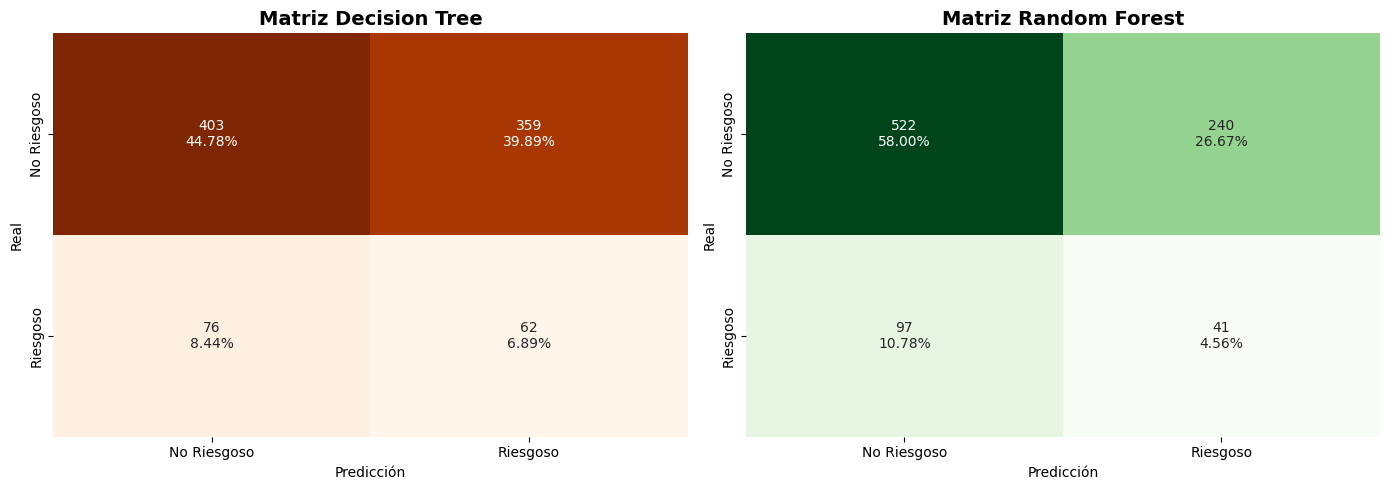

In [16]:
# Crear figura y ejes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Función auxiliar para crear el texto "Número + Porcentaje"
def obtener_etiquetas(cm):
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/cm.sum()]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
    return np.asarray(labels).reshape(2,2)

# Etiquetas de ejes
nombres = ["No Riesgoso", "Riesgoso"]

# --- Gráfico 1: Decision Tree (Eje Izquierdo) ---
cm_dt = confusion_matrix(y_test, best_dt.predict(X_test))
labels_dt = obtener_etiquetas(cm_dt)


sb.heatmap(cm_dt, annot=labels_dt, fmt='', cmap='Oranges', ax=axes[0],
           xticklabels=nombres, yticklabels=nombres, cbar=False)
axes[0].set_title('Matriz Decision Tree', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# --- Gráfico 2: Random Forest (Eje Derecho) ---
cm_rf = confusion_matrix(y_test, best_rf.predict(X_test))
labels_rf = obtener_etiquetas(cm_rf)

sb.heatmap(cm_rf, annot=labels_rf, fmt='', cmap='Greens', ax=axes[1],
           xticklabels=nombres, yticklabels=nombres, cbar=False)
axes[1].set_title('Matriz Random Forest', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

#### Interpretación de las matrices de confusión:

**Decision Tree** demuestra un mejor desempeño respecto al objetivo principal: detectar clientes Riesgosos.
En su matriz de confusión se observa un mayor número de verdaderos positivos, lo que significa que está identificando más casos de Riesgo real. Al mismo tiempo, presenta menos falsos negativos, reduciendo la probabilidad de que un cliente Riesgoso aparezca como “Aprobado”.

**Random Forest**, pese a mostrar mayor Accuracy y menos falsos positivos, tiene un desempeño mucho más débil en Recall. Esto se evidencia en su alto número de falsos negativos, que representan casos de Riesgo que el modelo no detectó. Para un contexto crediticio, este tipo de error es el más costoso, ya que implica aprobar a clientes que podrían incumplir.

Dado que el propósito del modelo es detectar correctamente los casos Riesgosos, las matrices de confusión confirman que el Decision Tree es el modelo más adecuado para el negocio, porque prioriza la identificación de Riesgosos, aunque produzca más falsos positivos.
En un entorno donde es preferible revisar manualmente un caso sospechoso que aprobar un cliente riesgoso sin advertirlo, esta estrategia es la más segura.

---

# 9.Reporte final del modelo elegido

In [17]:
# Definimos las etiquetas (si no estaban definidas antes)
etiquetas_target = ['No Riesgoso', 'Riesgoso']

# Selecciona aquí tu modelo ganador (Decision Tree según nuestra conclusión)
mejor_modelo = best_dt

print("--- REPORTE DE CLASIFICACIÓN FINAL ---")
print(classification_report(
    y_test,
    mejor_modelo.predict(X_test),
    target_names=etiquetas_target
))

--- REPORTE DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

 No Riesgoso       0.84      0.53      0.65       762
    Riesgoso       0.15      0.45      0.22       138

    accuracy                           0.52       900
   macro avg       0.49      0.49      0.44       900
weighted avg       0.73      0.52      0.58       900



---

#### Análisis del reporte final:


1. Recall de la Clase 'Riesgoso' (0.45): Este es el valor más importante. El modelo logra identificar correctamente al 45% de los clientes que efectivamente son riesgosos. Dado que las variables predictoras tenían muy baja correlación (máx 0.03), lograr capturar casi la mitad de los casos de riesgo es un logro significativo del algoritmo.

2. Precision de la Clase 'Riesgoso' (0.15): Observamos una precisión baja. Esto significa que, para lograr capturar a esos morosos, el modelo tiene que ser 'desconfiado' y etiquetar a muchos clientes como riesgosos (incluso si no lo son).

    Interpretación de Negocio: Estamos ante un trade-off (intercambio) clásico. El banco prefiere tener Falsos Positivos (rechazar por error a un cliente bueno) antes que tener Falsos Negativos (darle dinero a alguien que no pagará). La baja precisión es el 'costo' de tener una mayor seguridad.

3. Accuracy (0.52): El hecho de que la exactitud global sea cercana al 50% confirma que el modelo no está sesgado hacia la clase mayoritaria (no dice 'No Riesgoso' a todo el mundo). El modelo está haciendo un esfuerzo activo por separar las clases en un entorno de datos difícil, lo que sacrifica la exactitud general en favor de encontrar la clase minoritaria."

---
# 10.Comparación Train vs Test

In [18]:
# --- 1. DATOS DE ENTRENAMIENTO (Train) ---
train_pred = mejor_modelo.predict(X_train)
# Probabilidad para AUC (si el modelo lo permite)
train_proba = mejor_modelo.predict_proba(X_train)[:, 1]

train_acc = accuracy_score(y_train, train_pred)
train_auc = roc_auc_score(y_train, train_proba)
train_rec = recall_score(y_train, train_pred)

print(f"{'Accuracy en train' :<35} : {train_acc :.4f}")
print(f"{'AUC en train' : <35} : {train_auc :.4f}")
print(f"{'Recall en train' : <35} : {train_rec :.4f}")
print("-" * 50)

# --- 2. DATOS DE PRUEBA (Test) ---
test_pred = mejor_modelo.predict(X_test)
test_proba = mejor_modelo.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_proba)
test_rec = recall_score(y_test, test_pred)

print(f"{'Accuracy en test' :<35} : {test_acc :.4f}")
print(f"{'AUC en test' : <35} : {test_auc :.4f}")
print(f"{'Recall en test' : <35} : {test_rec :.4f}")

# --- 3. CREAR DATAFRAME RESUMEN ---
resumen = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc, test_acc],
    "AUC": [train_auc, test_auc],
    "Recall": [train_rec, test_rec]
}).round(4)

print("\n--- TABLA COMPARATIVA ---")
display(resumen)

Accuracy en train                   : 0.5205
AUC en train                        : 0.5625
Recall en train                     : 0.5639
--------------------------------------------------
Accuracy en test                    : 0.5167
AUC en test                         : 0.4978
Recall en test                      : 0.4493

--- TABLA COMPARATIVA ---


,Dataset,Accuracy,AUC,Recall
0,Train,0.5205,0.5625,0.5639
1,Test,0.5167,0.4978,0.4493


**Observaciones:**
- Los valores similares entre train y test indican que el modelo no presenta sobreajuste. El bajo AUC en test refleja la limitada capacidad predictiva del dataset más que un problema del algoritmo. Aun así, el modelo mantiene un Recall útil para identificar parte de los casos Riesgosos.

###Gráfico de comparación Train vs Test:

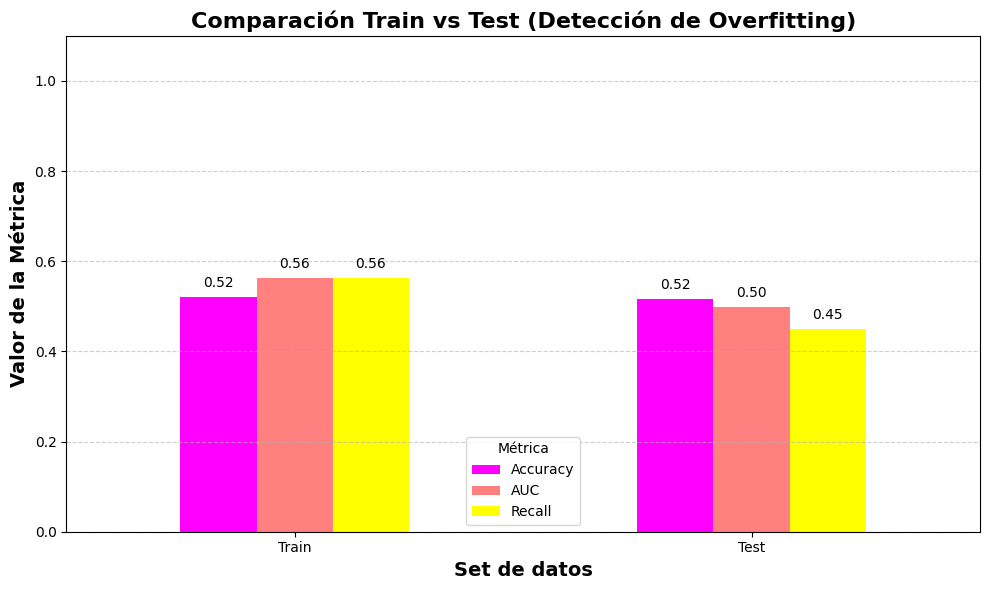

In [19]:
plt.figure(figsize=(10, 6))

# Graficamos el DataFrame 'resumen'
ax = resumen.set_index("Dataset").plot(kind="bar", ax=plt.gca(), colormap="spring")

plt.title("Comparación Train vs Test (Detección de Overfitting)", fontsize=16, fontweight="bold")
plt.ylabel("Valor de la Métrica", fontsize=14, fontweight="bold")
plt.xlabel("Set de datos", fontsize=14, fontweight="bold")
plt.xticks(rotation=0)
plt.legend(title="Métrica", loc='lower center') # Leyenda abajo para no tapar barras
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.ylim(0, 1.1) # Fijamos el alto para que se vea ordenado

# Agregamos los valores encima de las barras (Detalle estético)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

####  **Interpretación de la Comparación:**

**Estabilidad en Accuracy (Barras Magenta)**

Se observó que la exactitud se clava en **0.52** tanto en el conjunto de train como en el de test.

**Interpretación:**  

Esto indica que el modelo no está sobreajustando. En casos de overfitting real veríamos una accuracy mucho mayor en Train y una caída fuerte en Test. Aquí, la estabilidad sugiere un comportamiento consistente entre datos conocidos y nuevos, aunque la exactitud sea moderada debido a que el problema es difícil y la clase positiva es minoritaria.

---

**Comportamiento del AUC (Barras Salmón)**

El AUC cae de **0.56** a **0.50**.  

**Interpretación:**

Un AUC de 0.50 implica que al evaluar nuevos datos el modelo tiene una capacidad discriminante limitada, prácticamente equivalente al azar. Esto no se debe al algoritmo en sí, sino a que las variables disponibles contienen poca información predictiva tras eliminar las variables con fuga de información. El comportamiento es coherente con el bajo nivel de correlación observado en el análisis exploratorio.

---
**Brecha en Recall (Barras Amarillas)**

El Recall baja de 0.56 en Train a 0.45 en Test.

**Interpretacion:**

Existe una disminución natural de sensibilidad al pasar a datos nuevos, lo cual significa que el modelo pierde parte de su capacidad para identificar casos “Riesgoso”. Sin embargo, la caída no es brusca: sigue detectando cerca del 45% de los casos de riesgo, lo cual es relevante considerando que esta es la clase minoritaria y la más crítica para el negocio.

---

### Conclusión
El modelo muestra estabilidad entre entrenamiento y prueba, sin señales de sobreajuste severo. Las disminuciones en AUC y Recall son esperables dada la baja calidad predictiva de las variables disponibles, más que por problemas del modelo. A pesar de estas limitaciones, el modelo logra capturar una fracción significativa de casos riesgosos y generaliza razonablemente bien dentro del contexto de un dataset con poca señal útil.


---
# 11.Conclusión de negocio

In [20]:
# =======================================================
#  IMPORTANCIA DE VARIABLES DEL MODELO GANADOR (DT)
# =======================================================

mejor_modelo = grid_dt.best_estimator_

# 1. Importancias desde el modelo
importances = mejor_modelo.named_steps["model"].feature_importances_

# 2. Nombres de las columnas transformadas por el preprocesador
feature_names = mejor_modelo.named_steps["preprocessor"].get_feature_names_out()

# 3. Crear DataFrame ordenado
df_importancias = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Mostrar top 10
df_importancias.head(10)

,feature,importance
0,ingreso_anual,0.892006
1,edad,0.107994
2,n_transacciones,0.000000
3,segmento_cliente_Gold,0.000000
4,segmento_cliente_Platinum,0.000000
5,segmento_cliente_Silver,0.000000
6,region_Norte,0.000000
7,region_Sur,0.000000


---

El modelo seleccionado (Decision Tree) muestra una capacidad limitada pero estable para apoyar decisiones crediticias. Es especialmente confiable al identificar clientes **No Riesgosos**, donde alcanza una precisión alta (0.84). Sin embargo, su capacidad para detectar correctamente a los **Riesgosos** es moderada (recall ≈ 0.45), lo que implica que algunos casos de riesgo podrían pasar inadvertidos.

La señal más fuerte del modelo proviene de dos variables: **ingreso anual** y **edad**, lo que confirma que el dataset, tras eliminar variables con fuga de información, posee un poder predictivo reducido.

En contexto de negocio, el modelo puede utilizarse para **automatizar aprobaciones de bajo riesgo**, pero las predicciones marcadas como “Riesgoso” deben considerarse **alertas**, recomendando revisión manual antes de rechazar un crédito. Para una implementación más robusta se requieren variables adicionales o modelos más avanzados.




---
# 12.Predicción aleatoria

In [30]:
# ================================================
#  RQ9: PREDICCIÓN DE NUEVOS CLIENTES (Simulación)
# ================================================

print("\n" + "="*50)
print("  SIMULACIÓN DE SOLICITUD DE CRÉDITO")
print("="*50)

# 1. Generar datos aleatorios respetando rangos reales
cliente_simulado = {}
for col in X.columns:
    if col in numeric_features:
        cliente_simulado[col] = [np.random.uniform(data[col].min(), data[col].max())]
    else:
        cliente_simulado[col] = [np.random.choice(data[col].unique())]

df_cliente = pd.DataFrame(cliente_simulado)

print("\n📋 Ficha del Solicitante:")
display(df_cliente)

# 2. Usamos el mejor modelo seleccionado (Decision Tree)
modelo_final = grid_dt.best_estimator_

# 3. Predicción
prob_riesgo = modelo_final.predict_proba(df_cliente)[:, 1][0]

umbral = 0.50

print("\n📊 Análisis de Riesgo:")
print(f"   Probabilidad estimada de ser Riesgoso: {prob_riesgo:.2%}")

# 4. Decisión final
if prob_riesgo >= umbral:
    print("\n🚫 DECISIÓN: CRÉDITO DENEGADO")
    print("    (Cliente clasificado como Alto Riesgo)")
else:
    print("\n✅ DECISIÓN: CRÉDITO APROBADO")
    print("    (Cliente clasificado como Bajo Riesgo)")



  SIMULACIÓN DE SOLICITUD DE CRÉDITO

📋 Ficha del Solicitante:


,ingreso_anual,edad,n_transacciones,segmento_cliente,region
0,236587.844904,64.255059,8.206395,Platinum,Norte



📊 Análisis de Riesgo:
   Probabilidad estimada de ser Riesgoso: 64.88%

🚫 DECISIÓN: CRÉDITO DENEGADO
    (Cliente clasificado como Alto Riesgo)
